In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [5]:
rewards_eg = pd.read_pickle("../results/rewards_eg.pkl")
rewards_ucb = pd.read_pickle("../results/rewards_ucb.pkl")
rewards_ts = pd.read_pickle("../results/rewards_ts.pkl")

len(rewards_eg), len(rewards_ucb), len(rewards_ts)


(5000, 5000, 5000)

In [6]:
cum_eg = np.cumsum(rewards_eg)
cum_ucb = np.cumsum(rewards_ucb)
cum_ts = np.cumsum(rewards_ts)


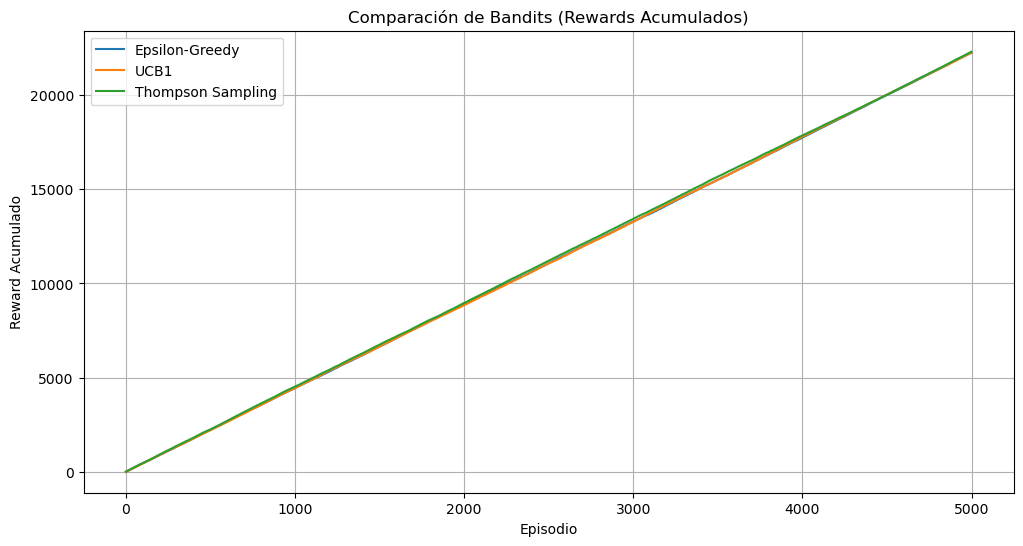

In [7]:
plt.figure(figsize=(12,6))
plt.plot(cum_eg, label="Epsilon-Greedy")
plt.plot(cum_ucb, label="UCB1")
plt.plot(cum_ts, label="Thompson Sampling")

plt.title("Comparación de Bandits (Rewards Acumulados)")
plt.xlabel("Episodio")
plt.ylabel("Reward Acumulado")
plt.legend()
plt.grid(True)
plt.show()


In [8]:
summary = pd.DataFrame({
    "Agente": ["Epsilon-Greedy", "UCB1", "Thompson Sampling"],
    "Reward Total": [
        cum_eg[-1],
        cum_ucb[-1],
        cum_ts[-1]
    ],
    "Reward Promedio": [
        np.mean(rewards_eg),
        np.mean(rewards_ucb),
        np.mean(rewards_ts)
    ]
})

summary


,Agente,Reward Total,Reward Promedio
0,Epsilon-Greedy,22237,4.4474
1,UCB1,22247,4.4494
2,Thompson Sampling,22299,4.4598


In [9]:
winner = summary.sort_values("Reward Total", ascending=False).iloc[0]
winner


Agente             Thompson Sampling
Reward Total                   22299
Reward Promedio               4.4598
Name: 2, dtype: object

In [10]:
print("Conclusiones del experimento:")
print("---------------------------------")
print(f"Agente ganador: {winner['Agente']}")
print(f"Reward total: {winner['Reward Total']:.2f}")
print(f"Reward promedio: {winner['Reward Promedio']:.4f}")

print("\nInterpretación:")
print("- Thompson Sampling suele explorar y explotar mejor.")
print("- UCB1 es más estable pero más conservador.")
print("- Epsilon-Greedy depende de su epsilon y explora más al azar.")


Conclusiones del experimento:
---------------------------------
Agente ganador: Thompson Sampling
Reward total: 22299.00
Reward promedio: 4.4598

Interpretación:
- Thompson Sampling suele explorar y explotar mejor.
- UCB1 es más estable pero más conservador.
- Epsilon-Greedy depende de su epsilon y explora más al azar.
